# 04. Model Building — Hybrid PyTorch + LightGBM Ensemble

This notebook trains a hybrid PyTorch MLP + LightGBM Regressor ensemble model to predict $\log_{10}(\text{views} + 1)$ across 8 niches, applying decay weights for video age, and saves the final model bundle to `src/model.joblib`.

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

sys.path.append('..')
from src.features import YouTubeFeatureExtractor
from src.recommender import PyTorchMLP, YouTubeRecommender

In [2]:
# Load processed feature matrix
features_path = '../data/processed/scaled_niche/features.csv'
if not os.path.exists(features_path):
    raise FileNotFoundError(f"Processed features not found at {features_path}. Run 03_eda_and_features.ipynb first.")

df_feat = pd.read_csv(features_path)
print(f"Loaded feature matrix of shape: {df_feat.shape}")

Loaded feature matrix of shape: (28314, 63)


In [3]:
# Define the complete pre-upload feature list
FEATURES_LIST = [
    'duration_minutes',
    'is_optimal_duration',
    'is_shorts',
    'title_char_count',
    'title_word_count',
    'title_has_number',
    'title_has_question',
    'title_has_exclamation',
    'title_has_colon',
    'title_has_money_ref',
    'title_has_all_caps',
    'title_emotional_trigger_count',
    'title_is_hindi_or_hinglish',
    'title_mentions_india',
    'title_sentiment_polarity',
    'title_sentiment_subjectivity',
    'tags_count',
    'hashtag_count',
    'has_hashtags',
    'description_char_count',
    'publish_hour_ist',
    'publish_day_of_week',
    'is_weekend',
    'is_prime_time',
    'log_channel_subscribers',
    'log_rolling_channel_baseline',
    'log_video_sequence_number',
    'log_channel_age_days_at_upload',
    'days_since_published',
    'log_days_since_published',
    'is_highly_edited',
    'niche_personal_finance',
    'niche_geopolitics_economy',
    'niche_tech_gadgets',
    'niche_gaming',
    'niche_comedy_entertainment',
    'niche_education_science',
    'niche_makeup_beauty',
    'niche_vlogging_lifestyle',
    'voice_type_human_own',
    'voice_type_ai_generated',
    'voice_type_music_only',
    'presentation_style_face_presenter',
    'presentation_style_faceless_broll',
    'presentation_style_animated_visuals'
]

# Ensure all features exist in DataFrame
FEATURES_LIST = [f for f in FEATURES_LIST if f in df_feat.columns]
print(f"Using {len(FEATURES_LIST)} features for model training:")
print(FEATURES_LIST)

Using 45 features for model training:
['duration_minutes', 'is_optimal_duration', 'is_shorts', 'title_char_count', 'title_word_count', 'title_has_number', 'title_has_question', 'title_has_exclamation', 'title_has_colon', 'title_has_money_ref', 'title_has_all_caps', 'title_emotional_trigger_count', 'title_is_hindi_or_hinglish', 'title_mentions_india', 'title_sentiment_polarity', 'title_sentiment_subjectivity', 'tags_count', 'hashtag_count', 'has_hashtags', 'description_char_count', 'publish_hour_ist', 'publish_day_of_week', 'is_weekend', 'is_prime_time', 'log_channel_subscribers', 'log_rolling_channel_baseline', 'log_video_sequence_number', 'log_channel_age_days_at_upload', 'days_since_published', 'log_days_since_published', 'is_highly_edited', 'niche_personal_finance', 'niche_geopolitics_economy', 'niche_tech_gadgets', 'niche_gaming', 'niche_comedy_entertainment', 'niche_education_science', 'niche_makeup_beauty', 'niche_vlogging_lifestyle', 'voice_type_human_own', 'voice_type_ai_genera

In [4]:
# Chronological split to evaluate forecasting generalization
# Sort descending by days_since_published (oldest first, newest last)
df_sorted = df_feat.sort_values('days_since_published', ascending=False).reset_index(drop=True)

X = df_sorted[FEATURES_LIST]
y = df_sorted['log_views']
days = df_sorted['days_since_published']

split_idx = int(len(X) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]
days_train, days_val = days.iloc[:split_idx], days.iloc[split_idx:]

print(f"Training set  : {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

Training set  : 22651 samples
Validation set: 5663 samples


In [5]:
# Compute linear decay sample weights
# Videos <= 1 year old get 1.0; older videos decay linearly to 0.3 up to 3 years
w_train = np.ones(len(X_train))
mask_tr = days_train > 365
w_train[mask_tr] = np.maximum(0.3, 1.0 - (days_train[mask_tr] - 365) / 730.0 * 0.7)

w_val = np.ones(len(X_val))
mask_val = days_val > 365
w_val[mask_val] = np.maximum(0.3, 1.0 - (days_val[mask_val] - 365) / 730.0 * 0.7)

In [6]:
# 1. Train LightGBM model
print("Training LightGBM Regressor...")
lgb_train = lgb.Dataset(X_train, label=y_train, weight=w_train)
lgb_val = lgb.Dataset(X_val, label=y_val, weight=w_val, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'feature_fraction': 0.8,
    'verbose': -1,
    'seed': 42
}

lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=300,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[lgb.log_evaluation(period=50)]
)

Training LightGBM Regressor...


[50]	training's rmse: 0.476463	valid_1's rmse: 0.820555
[100]	training's rmse: 0.433591	valid_1's rmse: 0.82705
[150]	training's rmse: 0.418414	valid_1's rmse: 0.834172
[200]	training's rmse: 0.407278	valid_1's rmse: 0.836889
[250]	training's rmse: 0.397503	valid_1's rmse: 0.839769
[300]	training's rmse: 0.389404	valid_1's rmse: 0.841875


In [7]:
# 2. Train PyTorch MLP model
print("Training PyTorch MLP...")
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
w_train_tensor = torch.tensor(w_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
w_val_tensor = torch.tensor(w_val, dtype=torch.float32).unsqueeze(1)

mlp = PyTorchMLP(X_train.shape[1])
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

epochs = 100
batch_size = 128

for epoch in range(1, epochs + 1):
    mlp.train()
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0
    
    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train_tensor[indices]
        batch_y = y_train_tensor[indices]
        batch_w = w_train_tensor[indices]
        
        optimizer.zero_grad()
        outputs = mlp(batch_x)
        loss = ( (outputs - batch_y) ** 2 * batch_w ).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(indices)
        
    epoch_loss /= X_train_tensor.size(0)
    if epoch % 20 == 0 or epoch == 1:
        mlp.eval()
        with torch.no_grad():
            val_out = mlp(X_val_tensor)
            val_loss = ( (val_out - y_val_tensor) ** 2 * w_val_tensor ).mean().item()
        print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {epoch_loss:.5f} | Val Loss: {val_loss:.5f}")

Training PyTorch MLP...
Epoch   1/100 | Train Loss: 6.18269 | Val Loss: 1.07836
Epoch  20/100 | Train Loss: 0.35597 | Val Loss: 0.43338
Epoch  40/100 | Train Loss: 0.29912 | Val Loss: 0.43136
Epoch  60/100 | Train Loss: 0.26242 | Val Loss: 0.40984
Epoch  80/100 | Train Loss: 0.24673 | Val Loss: 0.39499
Epoch 100/100 | Train Loss: 0.23687 | Val Loss: 0.42117


Validation Ensemble RMSE: 0.7177
Validation Ensemble MAE : 0.4950 (log10 views)
Validation Ensemble R2  : 0.6744


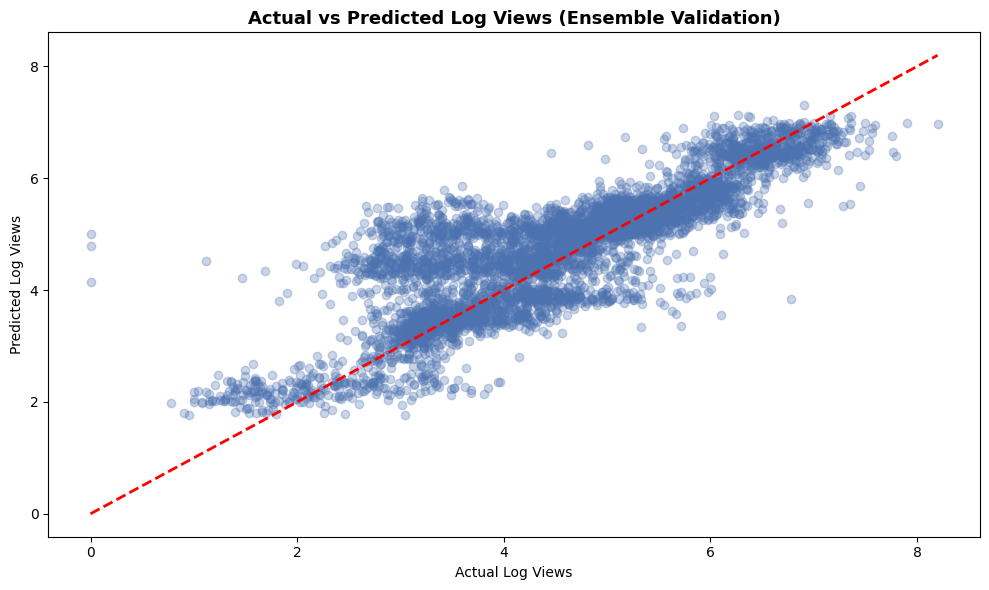

In [8]:
# 3. Evaluate Ensemble on Validation Set
lgb_pred = lgb_model.predict(X_val)
mlp.eval()
with torch.no_grad():
    mlp_pred = mlp(X_val_tensor).numpy().flatten()

ens_pred = 0.5 * lgb_pred + 0.5 * mlp_pred

ens_rmse = np.sqrt(mean_squared_error(y_val, ens_pred))
ens_mae = mean_absolute_error(y_val, ens_pred)
ens_r2 = r2_score(y_val, ens_pred)

print(f"Validation Ensemble RMSE: {ens_rmse:.4f}")
print(f"Validation Ensemble MAE : {ens_mae:.4f} (log10 views)")
print(f"Validation Ensemble R2  : {ens_r2:.4f}")

# Plot predictions vs actuals
plt.figure(figsize=(10, 6))
plt.scatter(y_val, ens_pred, alpha=0.3, color='#4C72B0')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Log Views (Ensemble Validation)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Log Views')
plt.ylabel('Predicted Log Views')
plt.tight_layout()
plt.savefig('../reports/ensemble_actual_vs_predicted.png', dpi=150)
plt.show()

In [9]:
# 4. Fit the global extractor on ALL data and save the model bundle
raw_path = '../data/raw/scaled_niche/videos.csv'
df_raw = pd.read_csv(raw_path)
extractor_global = YouTubeFeatureExtractor()
extractor_global.fit(df_raw)

bundle = {
    'lightgbm_model': lgb_model,
    'pytorch_model_state': mlp.state_dict(),
    'features_list': FEATURES_LIST,
    'extractor': extractor_global,
    'rmse': float(ens_rmse),
    'niche_medians': {n: float(df_raw[df_raw['niche'] == n]['view_count'].median())
                      for n in df_raw['niche'].unique()}
}

bundle_path = '../src/model.joblib'
joblib.dump(bundle, bundle_path)
print(f"✅ Model bundle successfully saved to: {bundle_path}")

✅ Model bundle successfully saved to: ../src/model.joblib


In [10]:
# 5. Demo prediction using YouTubeRecommender
recommender = YouTubeRecommender.load(bundle_path)
res = recommender.predict(
    title="How I Built a Profitable Faceless YouTube Channel in 30 Days",
    duration_minutes=14.0,
    publish_hour_ist=19,
    publish_day_of_week=3,
    niche='personal_finance',
    subscribers=25000,
    voice_type='human_own',
    presentation_style='faceless_broll',
    is_highly_edited=1
)

recommender.print_report(res)


                   CREATOR FORECASTING PLAYBOOK
 Proposed Title : How I Built a Profitable Faceless YouTube Channel in 30 Days
 Niche          : Personal Finance India
 Format/Style   : FACELESS_BROLL | HUMAN_OWN | HIGHLY EDITED
 Sub Baseline   : 2,500.0 views (preceding uploads median)
-----------------------------------------------------------------
 [1] VIEWS & VELOCITY HORIZONS
  Virality Tier : Stagnant (Underperforming baseline)
  Horizon    | Expected Views   | 80% Confidence Band    | V-Ratio 
  ---------- | ---------------- | ---------------------- | --------
  7  Days     | 1,036            | 124 - 8,598 | 0.41x
  30 Days     | 1,064            | 127 - 8,832 | 0.43x
  90 Days     | 1,085            | 130 - 9,008 | 0.43x
-----------------------------------------------------------------
 [2] TITLE ANALYSIS & REFRAMING
  Character Count  : 60 (Ideal: 45-65)
  Sentiment Tone   : Polarity 0.00 | Subjectivity 0.00

  Advisory Warnings:
    ✔ Add a curiosity question (e.g. 'Is this